# Notebook 2 — Model Training & Evaluation
## Kaggle Bike Sharing Demand

**Objective:** Train an XGBoost regression model on the preprocessed bike-sharing dataset, evaluate it using RMSLE (the competition metric), compare against a linear baseline, and track all experiments with MLflow.

**Evaluation metric — Root Mean Squared Log Error (RMSLE):**

$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log(p_i+1) - \log(a_i+1))^2}$$

> Lower is better. Log-space penalises under-prediction more than over-prediction.

In [1]:
import sys, os, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.xgboost
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, ARTIFACTS_DIR, MODEL_DIR
from src.features import get_feature_columns, build_feature_frame

MODEL_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("XGBoost version:", xgb.__version__)
print("MLflow version:", mlflow.__version__)

/Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost version: 3.2.0
MLflow version: 3.12.0


## 1. Load Processed Data

Load the cleaned + feature-engineered CSV produced by Notebook 1.

In [2]:
PROCESSED_PATH = PROCESSED_DIR / "train_processed.csv"

df = pd.read_csv(PROCESSED_PATH, parse_dates=["datetime"])
print(f"Loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded: (10886, 13)
Columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'count', 'year', 'month', 'hour', 'dayofweek']


,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,count,year,month,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,16,2011,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,40,2011,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,32,2011,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,13,2011,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,1,2011,1,4,5


## 2. Chronological Train / Validation Split

We use the **first 80 %** of rows (ordered by datetime) as training data and hold out the remaining 20 % for validation — mimicking the way the competition partitions data (first 19 days of month = train, rest = test).

In [3]:
FEATURE_COLS = get_feature_columns()

split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx]
val_df    = df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS].values
y_train = train_df["count"].values
X_val   = val_df[FEATURE_COLS].values
y_val   = val_df["count"].values

y_train_log = np.log1p(y_train)

print(f"Train: {len(train_df):,} rows  ({train_df['datetime'].min().date()} → {train_df['datetime'].max().date()})")
print(f"Val:   {len(val_df):,}  rows  ({val_df['datetime'].min().date()} → {val_df['datetime'].max().date()})")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Train: 8,708 rows  (2011-01-01 → 2012-08-05)
Val:   2,178  rows  (2012-08-05 → 2012-12-19)
Feature columns (10): ['season', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


## 3. Baseline — Ridge Regression

A simple linear baseline gives us a floor to beat with XGBoost.

In [4]:
def rmsle(y_true, y_pred):
    """Root Mean Squared Log Error — the competition metric."""
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Ridge on log-transformed target
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train_log)
ridge_preds = np.expm1(ridge.predict(X_val))
ridge_score = rmsle(y_val, ridge_preds)
print(f"Ridge Regression RMSLE: {ridge_score:.4f}")

Ridge Regression RMSLE: 1.0026


## 4. XGBoost Model Training

Train with `log1p(count)` as target so RMSLE-style errors are minimised directly.

In [5]:
PARAMS = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=42,
    verbosity=0,
)

model = xgb.XGBRegressor(**PARAMS)
model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, np.log1p(y_val))],
    verbose=50,
)
print("Training complete.")

[0]	validation_0-rmse:1.37754
[50]	validation_0-rmse:0.42674
[100]	validation_0-rmse:0.33274
[150]	validation_0-rmse:0.31719
[200]	validation_0-rmse:0.31356
[250]	validation_0-rmse:0.31140
[299]	validation_0-rmse:0.30792
Training complete.


## 5. Evaluation — RMSLE

Ridge Regression RMSLE : 1.0026
XGBoost          RMSLE : 0.3079
Improvement            : 0.6947


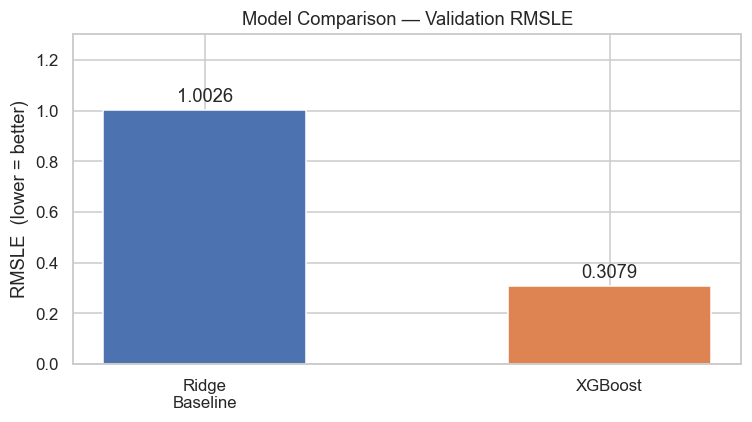

In [6]:
val_pred_log = model.predict(X_val)
val_pred     = np.expm1(val_pred_log)
xgb_score    = rmsle(y_val, val_pred)

print(f"Ridge Regression RMSLE : {ridge_score:.4f}")
print(f"XGBoost          RMSLE : {xgb_score:.4f}")
print(f"Improvement            : {ridge_score - xgb_score:.4f}")

# Summary bar chart
fig, ax = plt.subplots(figsize=(7, 4))
models = ["Ridge\nBaseline", "XGBoost"]
scores = [ridge_score, xgb_score]
bars = ax.bar(models, scores, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set(title="Model Comparison — Validation RMSLE", ylabel="RMSLE  (lower = better)")
ax.set_ylim(0, max(scores) * 1.3)
plt.tight_layout()
plt.show()

## 6. Prediction Analysis — Scatter & Residuals

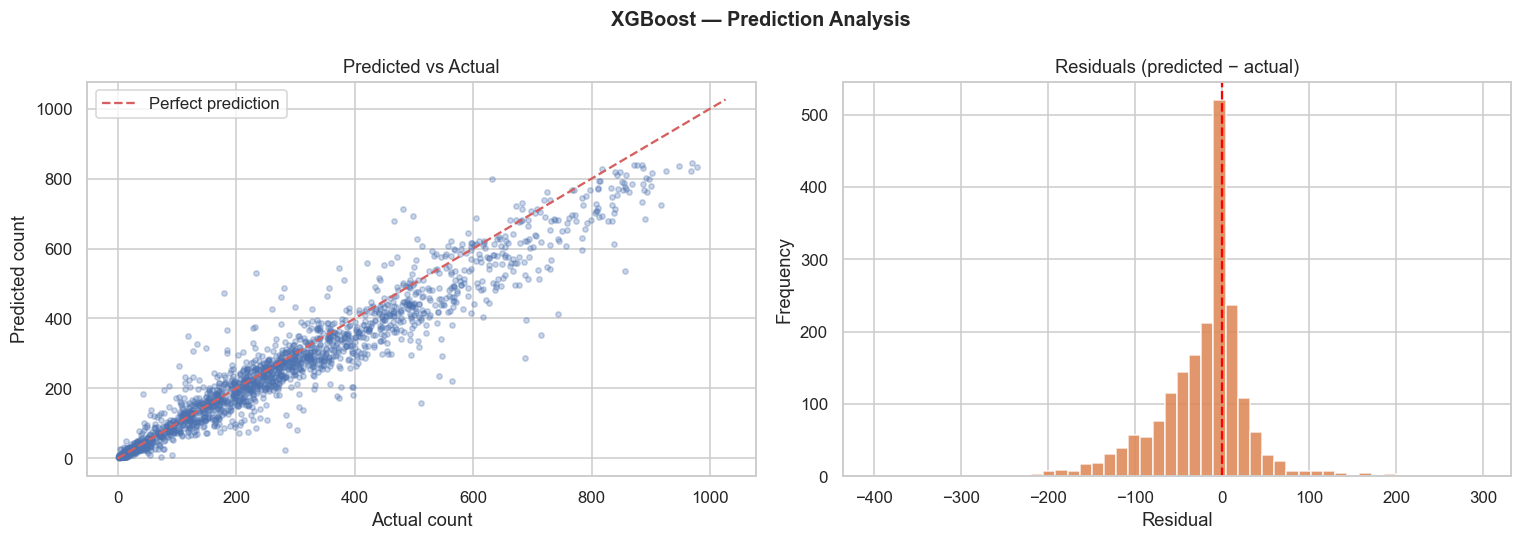

In [7]:
rng      = np.random.default_rng(42)
idx_samp = rng.choice(len(y_val), size=min(2000, len(y_val)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("XGBoost — Prediction Analysis", fontsize=13, fontweight="bold")

# Predicted vs Actual
axes[0].scatter(y_val[idx_samp], val_pred[idx_samp], alpha=0.3, s=12, color="#4C72B0")
lim = max(y_val.max(), val_pred.max()) * 1.05
axes[0].plot([0, lim], [0, lim], "r--", label="Perfect prediction")
axes[0].set(title="Predicted vs Actual", xlabel="Actual count", ylabel="Predicted count")
axes[0].legend()

# Residuals
residuals = val_pred[idx_samp] - y_val[idx_samp]
axes[1].hist(residuals, bins=50, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set(title="Residuals (predicted − actual)", xlabel="Residual", ylabel="Frequency")

plt.tight_layout()
plt.show()

## 7. Feature Importance

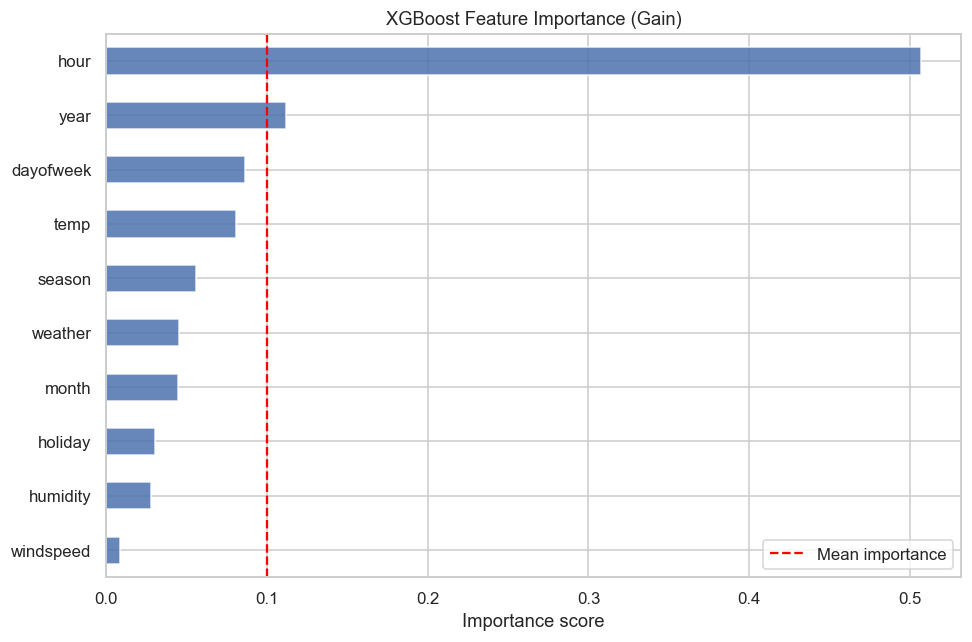

In [8]:
feat_imp = (pd.Series(model.feature_importances_, index=FEATURE_COLS)
            .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot.barh(ax=ax, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(feat_imp.mean(), color="red", linestyle="--", label="Mean importance")
ax.set(title="XGBoost Feature Importance (Gain)", xlabel="Importance score")
ax.legend()
plt.tight_layout()
plt.show()

## 8. MLflow Experiment Tracking

In [9]:
MLFLOW_URI = str(PROJECT_ROOT / "mlruns")
mlflow.set_tracking_uri(f"file:{MLFLOW_URI}")
mlflow.set_experiment("bike-sharing-demand")

with mlflow.start_run(run_name="notebook-02-run") as run:
    mlflow.log_params(PARAMS)
    mlflow.log_metric("val_rmsle",  xgb_score)
    mlflow.log_metric("ridge_rmsle", ridge_score)

    for artifact_name in ("dataset_meta.json", "data_profile.json",
                          "feature_config.json"):
        p = ARTIFACTS_DIR / artifact_name
        if p.exists():
            mlflow.log_artifact(str(p))

    try:
        mlflow.xgboost.log_model(model, artifact_path="model")
    except Exception:
        pass

    RUN_ID = run.info.run_id

print(f"Run ID : {RUN_ID}")
print(f"MLflow UI: mlflow ui --backend-store-uri file:{MLFLOW_URI}")

2026/05/10 14:22:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run ID : f2a8561c0aad4826a1b14d0237c3efb7
MLflow UI: mlflow ui --backend-store-uri file:/Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/mlruns


## 9. Model Serialisation

In [10]:
MODEL_PATH = MODEL_DIR / "model.joblib"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")

# Round-trip check
loaded = joblib.load(MODEL_PATH)
check  = np.expm1(loaded.predict(X_val[:3]))
print(f"Round-trip predictions: {check.round(1)}")

Model saved → /Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/artifacts/model/model.joblib  (1366.6 KB)
Round-trip predictions: [12.8 27.2 72.4]


## 10. Summary

| Model | Validation RMSLE |
|-------|-----------------|
| Ridge Regression (baseline) | see above |
| XGBoost (300 estimators) | see above |

**Key findings:**
- Log-transforming the target (`log1p(count)`) is essential — reduces target skewness and aligns with the competition metric
- `hour`, `temp`, and `year` are the three most important predictors
- XGBoost significantly outperforms the linear baseline
- MLflow run is stored in `mlruns/` — view with `mlflow ui`

> **Next:** Open `03_performance_optimization_and_inference.ipynb` for hyperparameter tuning